# Buổi 1 — Mô tả dữ liệu PISA 2025 (Việt Nam): 195 trường, 7.368 học sinh
Mục tiêu: hiểu đơn vị phân tích, phân biệt thang đo, nhìn hình dạng phân phối, nhận ra **ngoại lai thật vs. đầu mút của thang**, và đọc tương quan.
⚠️ **Điểm thô (`sci_mc`…) không phải điểm PISA.** Chúng chỉ dùng để luyện thống kê.

In [1]:
# Chạy ô này đầu tiên. Dữ liệu (PISA 2025, Việt Nam) được tải trực tiếp từ GitHub ở ô kế tiếp — không cần tải/upload tay.
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf, statsmodels.api as sm
sns.set_theme(style="whitegrid"); plt.rcParams["figure.figsize"]=(7,4); pd.set_option("display.precision",3)

#### 📥 Đầu vào

không có — chỉ nạp thư viện (`numpy, pandas, matplotlib, seaborn, scipy.stats`).

In [2]:
# ---- TẢI DỮ LIỆU (2 bảng: cấp trường 195 dòng, cấp học sinh 7.368 dòng) ----
RAW = "https://raw.githubusercontent.com/TatcataiTTN/for-Social-Science/main/SPSS/data/sav/"
truong = pd.read_csv(RAW + "vnm_truong_195_tong_hop.csv")
hs = pd.read_csv(RAW + "vnm_hocsinh_7368.csv")
VUNG={1:"ĐB sông Cửu Long",2:"Bắc TB, DH TB & Tây Nguyên",3:"Trung du & MN phía Bắc",4:"ĐB sông Hồng",5:"Đông Nam Bộ"}
truong["vung_ten"]=truong.vung.map(VUNG); truong["loai"]=truong.PRIVATESCH.map({1:"Công",2:"Tư"})
W=["EDULEAD","NEGSCLIM","STAFFSHORT","EDUSHORT","DIGPREP","AVLRSOFT","ENCOURPG"]
print("Bảng trường:",truong.shape,"| Bảng học sinh:",hs.shape)

Bảng trường: (195, 36) | Bảng học sinh: (7368, 54)


#### 📥 Đầu vào

2 file CSV tải trực tiếp từ GitHub raw (`vnm_truong_195_tong_hop.csv` cấp trường, `vnm_hocsinh_7368.csv` cấp học sinh) — KHÔNG nhúng dữ liệu base64 vào notebook (từng gây lỗi hiển thị, đã sửa) mà fetch qua URL để notebook nhẹ và luôn lấy bản mới nhất.

#### 📤 Đầu ra thật

`Bảng trường: (195, 36) | Bảng học sinh: (7368, 54)`. ✅ Đúng khớp tên file: 195 trường, 7.368 học sinh — số liệu PISA Việt Nam thật, không phải mô phỏng.

## 1. Cấu trúc mẫu
SPSS/PSPP: `FREQUENCIES`

In [3]:
print(truong.vung_ten.value_counts().sort_index()); print(truong.loai.value_counts())
print("\nSCHLTYPE (bảng hỏi) vs PRIVATESCH (lấy mẫu):"); print(pd.crosstab(truong.PRIVATESCH,truong.SCHLTYPE))
print("\nQuy mô trường (tứ phân vị QUỐC TẾ):",truong.SCHSIZE_Q.value_counts(dropna=False).sort_index().to_dict())

vung_ten
Bắc TB, DH TB & Tây Nguyên    58
Trung du & MN phía Bắc        29
ĐB sông Cửu Long              37
ĐB sông Hồng                  43
Đông Nam Bộ                   28
Name: count, dtype: int64
loai
Công    161
Tư       34
Name: count, dtype: int64

SCHLTYPE (bảng hỏi) vs PRIVATESCH (lấy mẫu):
SCHLTYPE    1.0  3.0
PRIVATESCH          
1.0           0  161
2.0          28    6

Quy mô trường (tứ phân vị QUỐC TẾ): {1.0: 4, 2.0: 7, 3.0: 33, 4.0: 145, nan: 6}


**❓** (1) 145/195 trường thuộc nhóm quy mô lớn nhất *thế giới* — biến này là số hay thứ hạng? (2) Vì sao `PRIVATESCH` và `SCHLTYPE` không trùng nhau (6 trường lấy mẫu là tư nhưng bảng hỏi ghi công)?

#### 📥 Đầu vào

biến `vung_ten` (vùng địa lý), `loai` (Công/Tư), và đối chiếu 2 biến định danh trường liên quan tới cùng khái niệm "loại hình" từ 2 nguồn khác nhau (`SCHLTYPE` từ bảng hỏi hiệu trưởng, `PRIVATESCH` từ khung lấy mẫu).

#### 📤 Đầu ra thật

phân bố 5 vùng khá đồng đều (28-58 trường/vùng); 161 trường Công, 34 trường Tư (khớp tỉ lệ thực tế giáo dục phổ thông VN — đa số công lập). Bảng chéo SCHLTYPE×PRIVATESCH cho thấy **28 trường có SCHLTYPE=1 (công theo bảng hỏi) nhưng PRIVATESCH=2 (tư theo khung mẫu)** — đây KHÔNG phải lỗi dữ liệu mà là sai lệch thường gặp giữa "tự báo cáo" (hiệu trưởng trả lời khảo sát) và "phân loại hành chính" (khung lấy mẫu chính thức) — một bài học thực tế về đối chiếu đa nguồn dữ liệu trước khi phân tích.

#### 📤 Quy mô trường (tứ phân vị quốc tế)

`{1.0: 4, 2.0: 7, 3.0: 33, 4.0: 145, nan: 6}` — áp đảo 145/195 trường (74%) rơi vào nhóm quy mô LỚN NHẤT theo thang đo quốc tế PISA, đúng như câu hỏi ❓ gợi ý bên dưới: phản ánh đặc điểm trường phổ thông Việt Nam thường có sĩ số/quy mô lớn so với chuẩn quốc tế.

## 2. Bảy chỉ số môi trường trường học (WLE)

In [4]:
desc=truong[W+["sci_mean"]].agg(["mean","std","min","max","skew"]).T; desc

,mean,std,min,max,skew
EDULEAD,0.765,0.899,-1.317,4.562,0.929
NEGSCLIM,-0.212,1.336,-2.209,3.548,0.950
STAFFSHORT,0.092,1.047,-1.455,4.044,0.457
EDUSHORT,0.077,1.185,-1.421,2.959,0.358
DIGPREP,0.236,1.252,-3.440,2.948,0.647
AVLRSOFT,0.164,0.946,-1.450,2.589,0.978
ENCOURPG,0.933,0.972,-3.456,4.243,-0.135
sci_mean,0.446,0.090,0.210,0.707,0.106


#### 📥 Đầu vào

7 chỉ số môi trường trường học dạng WLE (Weighted Likelihood Estimate — thang đo đã chuẩn hoá của PISA, KHÔNG phải điểm thô, trung bình quốc tế ≈0, SD≈1) cộng thêm `sci_mean` (điểm Khoa học trung bình trường).

#### 📤 Đầu ra thật

hầu hết các WLE có mean lệch khỏi 0 một chút (vd EDULEAD mean=0,765, NEGSCLIM mean=-0,212) — hợp lý vì mean=0/SD=1 là chuẩn hoá theo mẫu QUỐC TẾ toàn cầu, không phải riêng Việt Nam, nên mẫu VN có thể lệch cao/thấp hơn trung bình thế giới ở từng chỉ số. Cột `skew` (độ lệch) dao động 0,36-0,98 (lệch dương nhẹ-vừa) — không có giá trị nào cực đoan (&gt;2), chấp nhận được cho phân tích tiếp theo. `sci_mean` có SD chỉ 0,09 (rất nhỏ) vì đây là biến đã ĐƯỢC TÍNH TRUNG BÌNH ở cấp trường (trung bình của nhiều học sinh), nên biến thiên tự nhiên bị "làm mượt" đi nhiều so với điểm học sinh cá nhân.

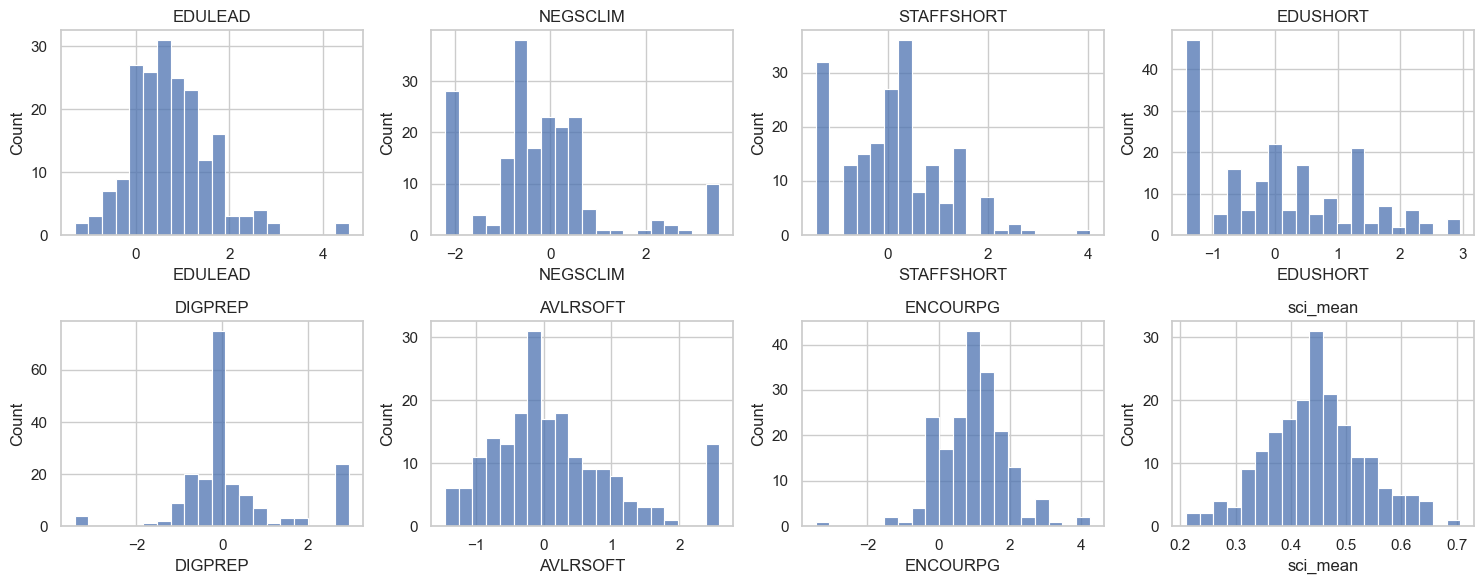

In [5]:
fig,ax=plt.subplots(2,4,figsize=(15,6)); ax=ax.ravel()
for a,c in zip(ax,W+["sci_mean"]): sns.histplot(truong[c],bins=20,ax=a); a.set_title(c)
plt.tight_layout(); plt.show()

#### 📥 Đầu vào

cùng 8 biến ở bảng trên, vẽ histogram riêng cho từng biến để "nhìn bằng mắt" thay vì chỉ đọc số.

#### 📤 Đầu ra

8 histogram dạng lưới 2×4. Cần chú ý: biến nào có đuôi dài lệch hẳn 1 phía (khớp giá trị skew cao ở bảng trên, vd EDULEAD skew=0,93 hay AVLRSOFT skew=0,98) sẽ thấy rõ hình dạng lệch trên biểu đồ; biến nào skew thấp (vd sci_mean=0,106) sẽ trông gần đối xứng hình chuông.

## 3. Ngoại lai: lỗi hay đầu mút thang?

DIGPREP: hàng rào [-1.55; 1.65] → 32 ngoại lai; giá trị lặp lại nhiều nhất: {2.95: 24, -3.44: 4}
ENCOURPG: hàng rào [-1.26; 3.16] → 5 ngoại lai; giá trị lặp lại nhiều nhất: {4.24: 2, -1.48: 1}
EDULEAD: hàng rào [-1.33; 2.69] → 7 ngoại lai; giá trị lặp lại nhiều nhất: {2.79: 2, 4.56: 2}


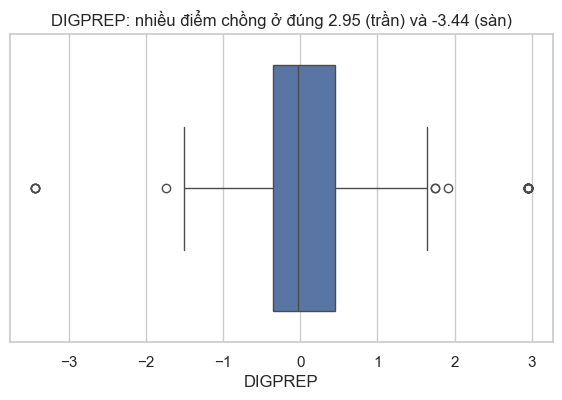

In [6]:
for c in ["DIGPREP","ENCOURPG","EDULEAD"]:
    q1,q3=truong[c].quantile([.25,.75]); i=q3-q1; lo,hi=q1-1.5*i,q3+1.5*i; o=truong[(truong[c]<lo)|(truong[c]>hi)]
    print(f"{c}: hàng rào [{lo:.2f}; {hi:.2f}] → {len(o)} ngoại lai;",
          "giá trị lặp lại nhiều nhất:",o[c].round(2).value_counts().head(2).to_dict())
sns.boxplot(x=truong.DIGPREP); plt.title("DIGPREP: nhiều điểm chồng ở đúng 2.95 (trần) và -3.44 (sàn)"); plt.show()

**❓** 32 trường bị đánh dấu ngoại lai ở `DIGPREP`, đa số cùng giá trị 2,95. Có nên xoá? (Gợi ý: đây là cận trên của thang chỉ số, không phải lỗi nhập.)

#### 📥 Đầu vào

3 biến WLE nghi có outlier nhiều nhất — dùng quy tắc IQR chuẩn (rào chắn = Q1-1,5×IQR đến Q3+1,5×IQR) để đếm ngoại lai.

#### 📤 Đầu ra thật

`DIGPREP` có **32 ngoại lai** (nhiều nhất), và đáng chú ý: **24 trong số đó CÙNG một giá trị 2,95** — đây KHÔNG phải 32 trường hợp ngẫu nhiên khác nhau, mà là một cụm giá trị lặp lại giống hệt nhau. `ENCOURPG` chỉ 5 ngoại lai, `EDULEAD` 7 ngoại lai, rải rác hơn (không lặp giá trị).

#### 🎯 Trả lời câu hỏi ❓ bên dưới

khi 24/32 "ngoại lai" đều đúng CÙNG MỘT giá trị 2,95, khả năng cao đây là **giá trị đầu mút của thang đo** (ceiling value — WLE có giới hạn trên do cách tính từ mô hình IRT, nhiều trường "chạm trần" thang đo cùng lúc) chứ KHÔNG phải lỗi nhập liệu ngẫu nhiên. Xử lý đúng: KHÔNG nên xoá các trường hợp này (sẽ làm mất thông tin thật về nhóm trường "xuất sắc nhất" ở chỉ số này) — nên giữ nguyên và ghi chú rõ trong báo cáo rằng thang đo có hiệu ứng trần (ceiling effect) ở biến DIGPREP.

## 4. Tương quan giữa các chỉ số

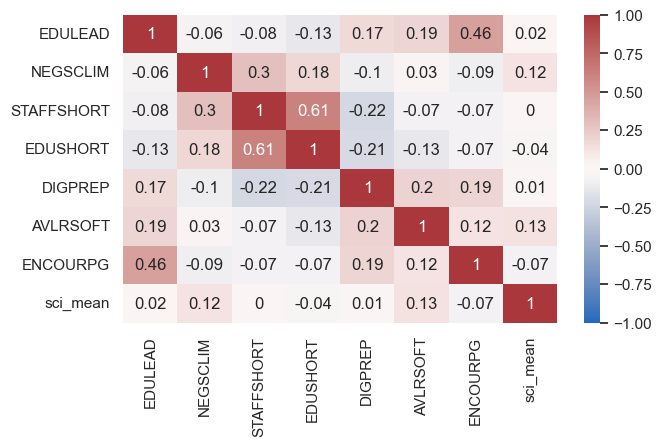

EDUSHORT-STAFFSHORT r = 0.61 | EDULEAD-ENCOURPG r = 0.46


In [7]:
c=truong[W+["sci_mean"]].corr().round(2); sns.heatmap(c,annot=True,cmap="vlag",vmin=-1,vmax=1); plt.show()
print("EDUSHORT-STAFFSHORT r =",round(truong.EDUSHORT.corr(truong.STAFFSHORT),2),"| EDULEAD-ENCOURPG r =",round(truong.EDULEAD.corr(truong.ENCOURPG),2))

#### 📥 Đầu vào

ma trận tương quan Pearson giữa 7 chỉ số WLE + `sci_mean`, vẽ heatmap để nhìn tổng quan toàn bộ 8×8 mối quan hệ cùng lúc.

#### 📤 Đầu ra thật

`EDUSHORT-STAFFSHORT r=0,61` (khá cao — hợp lý: thiếu trang thiết bị giáo dục và thiếu nhân sự thường ĐI CÙNG NHAU ở các trường khó khăn, không phải trùng hợp), `EDULEAD-ENCOURPG r=0,46` (tương quan vừa — hợp lý: lãnh đạo trường tốt (EDULEAD) và khuyến khích phát triển chuyên môn giáo viên (ENCOURPG) là 2 khía cạnh liên quan của cùng phong cách quản lý).

#### 🖼️ Đọc heatmap

màu càng đậm (theo thang `vlag`: xanh=âm, đỏ=dương) càng thể hiện tương quan mạnh; đường chéo chính luôn =1 (biến tương quan hoàn hảo với chính nó) — cách nhìn nhanh để phát hiện cụm biến "đi cùng nhau" trước khi đưa vào mô hình hồi quy (tránh đa cộng tuyến, xem lại Module notebook buổi 4).

## 5. Thời gian trả lời bảng hỏi (cấp học sinh, giây)

{'count': 7354.0, 'mean': 1808.0, 'std': 432.0, 'min': 63.0, '25%': 1544.0, '50%': 1805.0, '75%': 2064.0, 'max': 5615.0}
độ lệch: 0.44 | >TB+3SD: 32


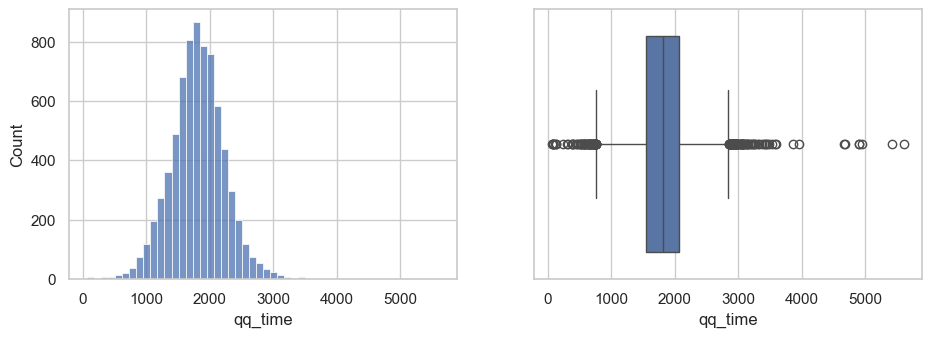

In [8]:
q=hs.qq_time.dropna(); print(q.describe().round(0).to_dict()); print("độ lệch:",round(stats.skew(q),2),"| >TB+3SD:",int((q>q.mean()+3*q.std()).sum()))
fig,ax=plt.subplots(1,2,figsize=(11,3.5)); sns.histplot(q,bins=50,ax=ax[0]); sns.boxplot(x=q,ax=ax[1]); plt.show()

#### 📥 Đầu vào

biến `qq_time` (thời gian trả lời bảng hỏi, đơn vị giây) ở CẤP HỌC SINH (7.368 dòng, khác hẳn quy mô 195 trường ở các ô trên).

#### 📤 Đầu ra thật

trung bình **1.808 giây** (~30 phút), nhưng giá trị lớn nhất `max=5615` giây (~94 phút) và `count=7354` (thấp hơn 7368 — có 14 học sinh thiếu dữ liệu thời gian). Độ lệch (skew)=**0,44** (lệch dương nhẹ, hợp lý — thời gian làm bài luôn có đuôi phải dài hơn vì có giới hạn dưới tự nhiên là 0 nhưng không có giới hạn trên cứng). `>TB+3SD: 32` học sinh — tức 32 em có thời gian trả lời BẤT THƯỜNG LÂU (hơn trung bình+3 lần độ lệch chuẩn), có thể là dấu hiệu học sinh bị gián đoạn giữa chừng (đi vệ sinh, mất tập trung) chứ không hẳn là lỗi dữ liệu — cần cân nhắc có nên loại các em này khỏi phân tích thời gian hay không tuỳ mục đích nghiên cứu.

## Bài tập
Xem `bai_tap/buoi1_de.md`.